# 03 — Exploratory Data Analysis (EDA) & Visualization

Notebook này tập trung vào **khám phá và trực quan hóa dữ liệu** đã được làm sạch từ bước `02_data_cleanning.ipynb`.

## Mục tiêu
- Phân tích phân bố nhãn, chủ đề, nguồn dữ liệu
- Khám phá đặc trưng ngôn ngữ phân biệt giữa **Human (0)** và **AI-generated (1)**
- Trực quan hóa mối quan hệ giữa các biến
- Phân tích từ và bigram phổ biến
- Hỗ trợ trả lời **RQ1**: Đặc trưng ngôn ngữ nào phân biệt rõ nhất văn bản con người và AI?

## Đồng bộ với hệ thống
- Đường dẫn: sử dụng `src.path`
- Dữ liệu đầu vào: `data/processed/processed_data.csv` (đã làm sạch)
- Tên cột chuẩn: `text_clean`, `label`, `prompt_name`, `source`, `word_count_clean`
- Định nghĩa nhãn: **0 = Human**, **1 = AI-generated**
- Đặc trưng: đồng bộ với `LinguisticFeatureExtractor` trong `src/pipelinebuilder.py`
- Thư mục đầu ra: `results/figures/`

## 1. Import thư viện và thiết lập đường dẫn

In [1]:
import sys
from pathlib import Path
import re
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Thêm thư mục gốc vào sys.path để import src
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Sử dụng đường dẫn chuẩn từ src.path
from src.path import (
    PROJECT_ROOT, DATA_DIR, PROCESSED_DATA_DIR,
    PROCESSED_DATA_FILE, FEATURE_DATA_FILE
)
from src.pipelinebuilder import (
    validate_and_convert_label, load_cleaned_data,
    LinguisticFeatureExtractor, STANDARD_COLUMNS, LABEL_HUMAN, LABEL_AI
)

# Thư mục lưu hình ảnh
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

# Màu sắc chuẩn cho 2 nhãn
COLORS = {
    LABEL_HUMAN: '#2563eb',   # Blue - Human
    LABEL_AI: '#f59e0b'       # Amber - AI-generated
}
LABEL_NAMES = {
    LABEL_HUMAN: 'Human (0)',
    LABEL_AI: 'AI-generated (1)'
}

print(f"✓ PROJECT_ROOT: {PROJECT_ROOT.resolve()}")
print(f"✓ PROCESSED_DATA_FILE: {PROCESSED_DATA_FILE.resolve()}")
print(f"✓ FIGURES_DIR: {FIGURES_DIR.resolve()}")

✓ PROJECT_ROOT: H:\FPT\4\DAP\Project-19\AI-Generated-Text-Essay-Detection
✓ PROCESSED_DATA_FILE: H:\FPT\4\DAP\Project-19\AI-Generated-Text-Essay-Detection\data\processed\processed_data.csv
✓ FIGURES_DIR: H:\FPT\4\DAP\Project-19\AI-Generated-Text-Essay-Detection\results\figures


## 2. Load dữ liệu đã làm sạch

In [2]:
# Load dữ liệu đã làm sạch (tự động chuyển label về int 0/1)
df = load_cleaned_data()

print(f"\n=== Thông tin dữ liệu ===")
print(f"Số dòng: {len(df):,}")
print(f"Số cột: {len(df.columns)}")
print(f"Các cột: {list(df.columns)}")
print(f"\n=== 5 dòng đầu tiên ===")
display(df.head())

✓ Đã load dữ liệu từ: H:\FPT\4\DAP\Project-19\AI-Generated-Text-Essay-Detection\data\processed\processed_data.csv
  - 44,854 dòng × 5 cột
  - Label đã chuyển thành int 0/1

=== Thông tin dữ liệu ===
Số dòng: 44,854
Số cột: 5
Các cột: ['label', 'prompt_name', 'source', 'text_clean', 'word_count_clean']

=== 5 dòng đầu tiên ===


,label,prompt_name,source,text_clean,word_count_clean
0,0,Phones and driving,persuade_corpus,phones modern humans today are always on their...,379
1,0,Phones and driving,persuade_corpus,this essay will explain if drivers should or s...,366
2,0,Phones and driving,persuade_corpus,driving while the use of cellular devices toda...,178
3,0,Phones and driving,persuade_corpus,phones driving drivers should not be able to u...,211
4,0,Phones and driving,persuade_corpus,cell phone operation while driving the ability...,332


## 3. Trích xuất đặc trưng ngôn ngữ (đồng bộ với pipelinebuilder)

Sử dụng `LinguisticFeatureExtractor` từ `src/pipelinebuilder.py` để trích xuất **9 đặc trưng ngôn ngữ chuẩn** phục vụ RQ1.

In [3]:
# Trích xuất đặc trưng ngôn ngữ
extractor = LinguisticFeatureExtractor()
print("Đang trích xuất đặc trưng ngôn ngữ...")
features = extractor.transform(df[STANDARD_COLUMNS['text']])
feature_names = extractor.get_feature_names()

# Thêm vào DataFrame
for i, name in enumerate(feature_names):
    df[name] = features[:, i]

print(f"✓ Đã trích xuất {len(feature_names)} đặc trưng ngôn ngữ:")
for name in feature_names:
    print(f"  - {name}")

print(f"\n=== DataFrame sau khi thêm đặc trưng ===")
print(f"Số cột: {len(df.columns)}")
display(df[['label', 'prompt_name', 'source'] + feature_names].head())

Đang trích xuất đặc trưng ngôn ngữ...
✓ Đã trích xuất 9 đặc trưng ngôn ngữ:
  - avg_sentence_length
  - sentence_length_std
  - avg_word_length
  - ttr
  - avg_complexity
  - function_word_ratio
  - content_word_ratio
  - punctuation_density
  - doc_length_log

=== DataFrame sau khi thêm đặc trưng ===
Số cột: 14


,label,prompt_name,source,avg_sentence_length,sentence_length_std,avg_word_length,ttr,avg_complexity,function_word_ratio,content_word_ratio,punctuation_density,doc_length_log
0,0,Phones and driving,persuade_corpus,13.551724,6.965858,4.061069,0.468193,0.103448,0.493639,0.506361,0.081425,5.976351
1,0,Phones and driving,persuade_corpus,18.600000,5.132251,4.443548,0.430108,1.100000,0.473118,0.526882,0.112903,5.921578
2,0,Phones and driving,persuade_corpus,25.714285,13.843144,4.705555,0.583333,0.857143,0.461111,0.538889,0.072222,5.198497
3,0,Phones and driving,persuade_corpus,17.750000,3.722119,4.643192,0.488263,0.666667,0.469484,0.530516,0.093897,5.365976
4,0,Phones and driving,persuade_corpus,23.785715,9.298069,4.627628,0.564565,0.857143,0.486486,0.513514,0.078078,5.811141


## 4. Phân bố nhãn, chủ đề và nguồn

=== Phân bố nhãn ===


,label,label_name,count,percent
0,0,Human (0),27359,61.0
1,1,AI-generated (1),17495,39.0



Số chủ đề (prompt_name): 15
Số nguồn (source): 17


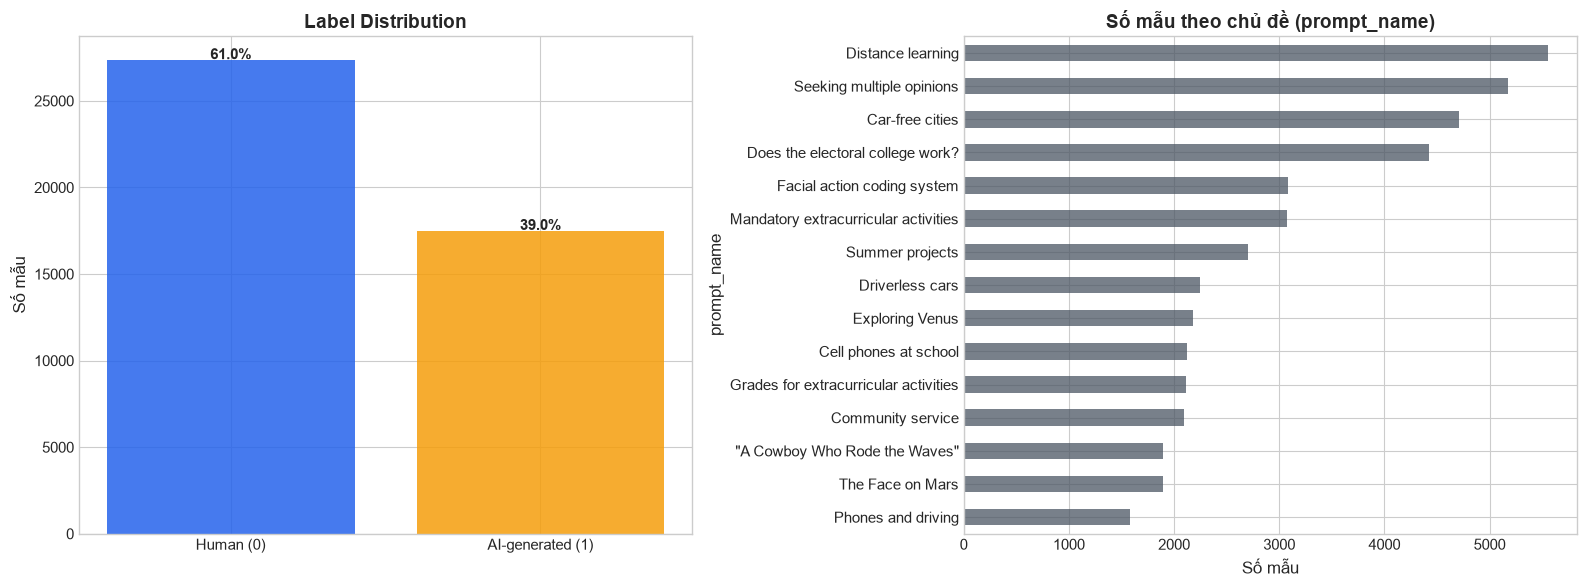

In [4]:
# Bảng phân bố nhãn
label_dist = df['label'].value_counts().sort_index()
label_table = pd.DataFrame({
    'label': label_dist.index,
    'label_name': label_dist.index.map(LABEL_NAMES),
    'count': label_dist.values,
    'percent': (label_dist.values / len(df) * 100).round(2)
})
print("=== Phân bố nhãn ===")
display(label_table)

print(f"\nSố chủ đề (prompt_name): {df['prompt_name'].nunique()}")
print(f"Số nguồn (source): {df['source'].nunique()}")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ phân bố nhãn
bars = axes[0].bar(
    label_table['label_name'], label_table['count'],
    color=[COLORS[LABEL_HUMAN], COLORS[LABEL_AI]], alpha=0.85
)
axes[0].set_title('Label Distribution', fontweight='bold')
axes[0].set_ylabel('Số mẫu')
for bar, pct in zip(bars, label_table['percent']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{pct}%", ha='center', fontweight='bold')

# Biểu đồ phân bố theo chủ đề
prompt_counts = df['prompt_name'].value_counts().sort_values(ascending=True)
prompt_counts.plot.barh(ax=axes[1], color='#4b5563', alpha=0.75)
axes[1].set_title('Số mẫu theo chủ đề (prompt_name)', fontweight='bold')
axes[1].set_xlabel('Số mẫu')

fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_label_prompt_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Phân tích độ dài văn bản theo nhãn

=== Thống kê độ dài văn bản (word_count_clean) theo nhãn ===


,count,mean,median,std,min,max
label,,,,,,
Human (0),27359,420.13,385.0,190.55,143,1656
AI-generated (1),17495,331.27,328.0,95.00,42,806


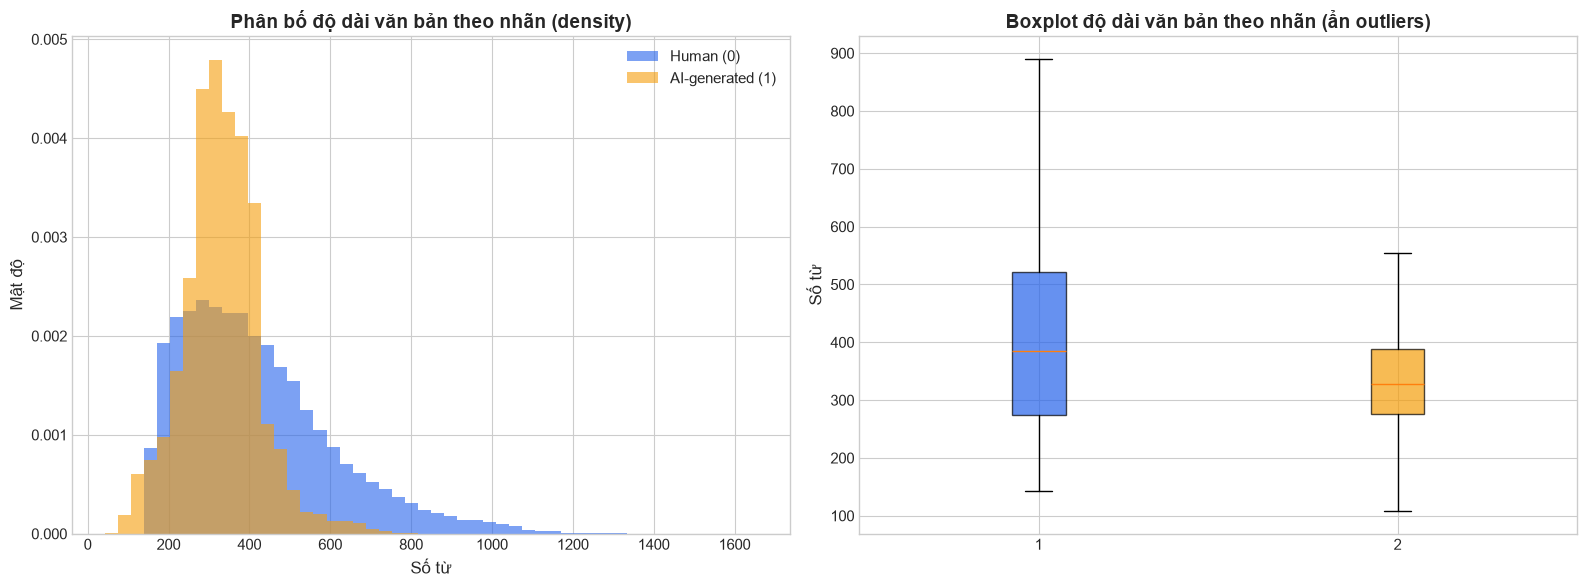

In [7]:
# Thống kê độ dài theo nhãn
length_stats = df.groupby('label')['word_count_clean'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
length_stats.index = length_stats.index.map(LABEL_NAMES)
print("=== Thống kê độ dài văn bản (word_count_clean) theo nhãn ===")
display(length_stats)

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram độ dài từ
bins = np.linspace(df['word_count_clean'].min(), df['word_count_clean'].max(), 51)
for label in [LABEL_HUMAN, LABEL_AI]:
    subset = df[df['label'] == label]['word_count_clean']
    axes[0].hist(subset, bins=bins, alpha=0.6, density=True,
                 label=LABEL_NAMES[label], color=COLORS[label])
axes[0].set_title('Phân bố độ dài văn bản theo nhãn (density)', fontweight='bold')
axes[0].set_xlabel('Số từ')
axes[0].set_ylabel('Mật độ')
axes[0].legend()

# Boxplot độ dài từ
box_data = [df[df['label'] == l]['word_count_clean'] for l in [LABEL_HUMAN, LABEL_AI]]
bp = axes[1].boxplot(box_data, label=[LABEL_NAMES[l] for l in [LABEL_HUMAN, LABEL_AI]],
                     showfliers=False, patch_artist=True)
for patch, color in zip(bp['boxes'], [COLORS[LABEL_HUMAN], COLORS[LABEL_AI]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Boxplot độ dài văn bản theo nhãn (ẩn outliers)', fontweight='bold')
axes[1].set_ylabel('Số từ')

fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_text_length_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Phân tích đặc trưng ngôn ngữ theo nhãn (RQ1)

So sánh 9 đặc trưng ngôn ngữ giữa **Human** và **AI-generated**.

In [8]:
# Bảng thống kê chi tiết các đặc trưng ngôn ngữ
linguistic_stats = df.groupby('label')[feature_names].agg(['mean', 'median', 'std']).round(4)
linguistic_stats.index = linguistic_stats.index.map(LABEL_NAMES)
print("=== Thống kê đặc trưng ngôn ngữ theo nhãn ===")
display(linguistic_stats)

# Tính chênh lệch tương đối giữa AI và Human
print("\n=== Chênh lệch tương đối (AI / Human - 1) ===")
human_means = df[df['label'] == LABEL_HUMAN][feature_names].mean()
ai_means = df[df['label'] == LABEL_AI][feature_names].mean()
diff_ratio = (ai_means / human_means - 1) * 100
diff_df = pd.DataFrame({
    'Human_mean': human_means.round(4),
    'AI_mean': ai_means.round(4),
    'Diff_percent': diff_ratio.round(2)
}).sort_values('Diff_percent', key=abs, ascending=False)
display(diff_df)

=== Thống kê đặc trưng ngôn ngữ theo nhãn ===


avg_sentence_length                   sentence_length_std  \
                                mean   median      std                mean   
label                                                                        
Human (0)                  21.713499  19.6667  14.7317              9.7376   
AI-generated (1)           19.040800  19.0000   3.7794              6.4693   

                                 avg_word_length                     ttr  ...  \
                  median     std            mean  median     std    mean  ...   
label                                                                     ...   
Human (0)         8.4886  6.8197          4.3628  4.3553  0.3127  0.4389  ...   
AI-generated (1)  6.1909  1.9642          4.8661  4.8841  0.5176  0.4702  ...   

                 function_word_ratio content_word_ratio                  \
                                 std               mean  median     std   
label                                                                     
Human (0)                     0.0448             0.4990  0.4977  0.0448   
AI-generated (1)              0.0549             0.5453  0.5392  0.0549   

                 punctuation_density                 doc_length_log          \
                                mean  median     std           mean  median   
label                                                                         
Human (0)                      0.084  0.0833  0.0262         5.9558  5.9636   
AI-generated (1)               0.113  0.1072  0.0299         5.7719  5.8141   

                          
                     std  
label                     
Human (0)         0.4392  
AI-generated (1)  0.3144  

[2 rows x 27 columns]


=== Chênh lệch tương đối (AI / Human - 1) ===


,Human_mean,AI_mean,Diff_percent
avg_complexity,0.663400,1.0990,65.650002
punctuation_density,0.084000,0.1130,34.540001
sentence_length_std,9.737600,6.4693,-33.560001
avg_sentence_length,21.713499,19.0408,-12.310000
avg_word_length,4.362800,4.8661,11.540000
content_word_ratio,0.499000,0.5453,9.270000
function_word_ratio,0.501000,0.4547,-9.240000
ttr,0.438900,0.4702,7.110000
doc_length_log,5.955800,5.7719,-3.090000


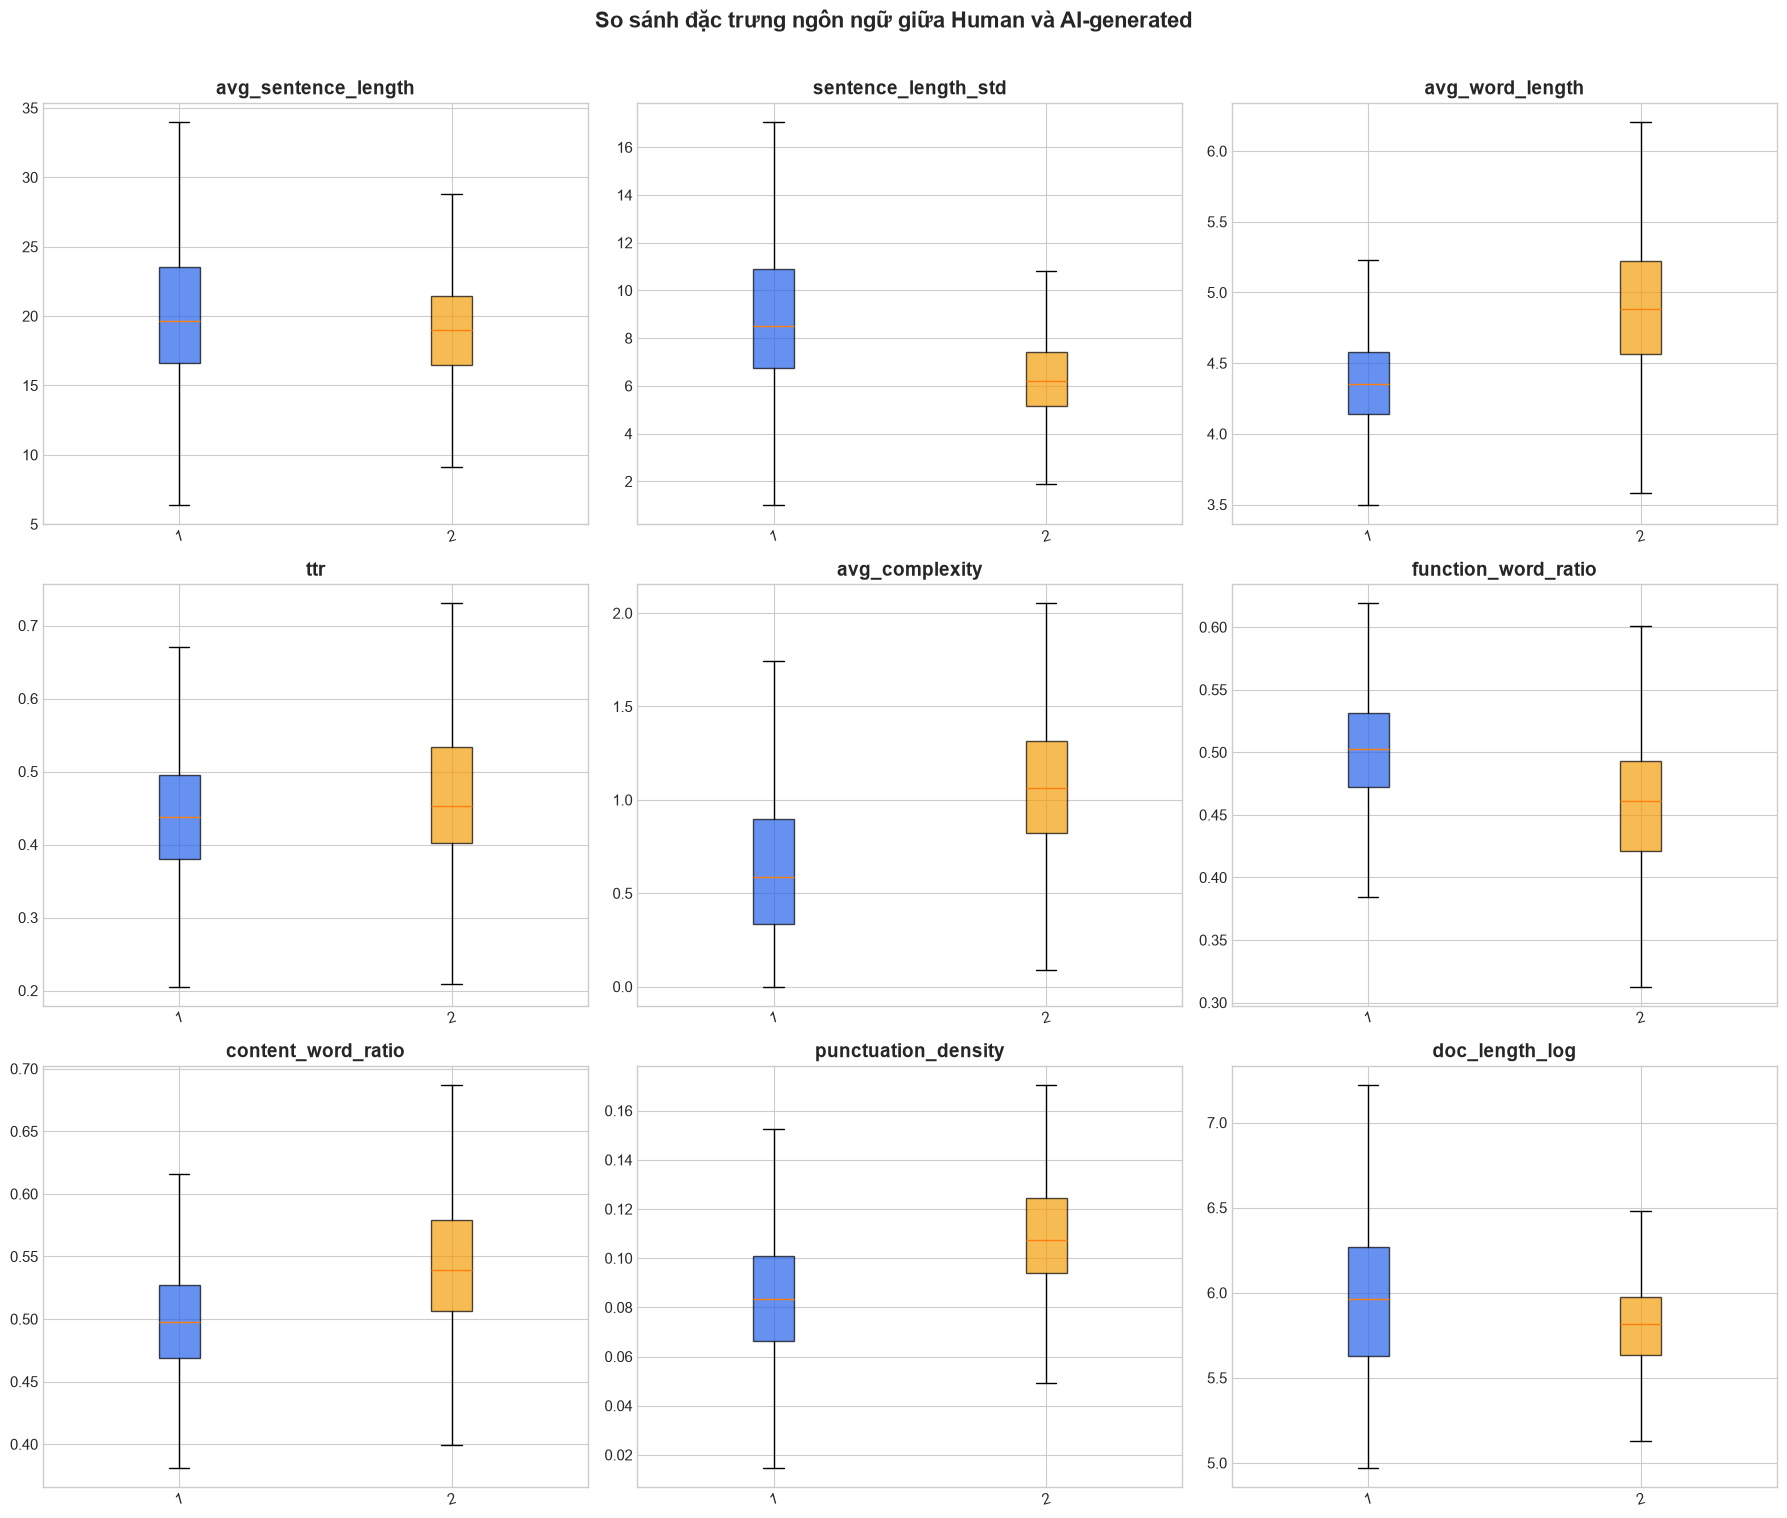

In [10]:
# Vẽ boxplot cho từng đặc trưng ngôn ngữ
n_features = len(feature_names)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, feat in enumerate(feature_names):
    ax = axes[idx]
    box_data = [df[df['label'] == l][feat] for l in [LABEL_HUMAN, LABEL_AI]]
    bp = ax.boxplot(box_data, label=[LABEL_NAMES[l] for l in [LABEL_HUMAN, LABEL_AI]],
                    showfliers=False, patch_artist=True)
    for patch, color in zip(bp['boxes'], [COLORS[LABEL_HUMAN], COLORS[LABEL_AI]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

# Ẩn các axes thừa
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('So sánh đặc trưng ngôn ngữ giữa Human và AI-generated',
             fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_linguistic_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

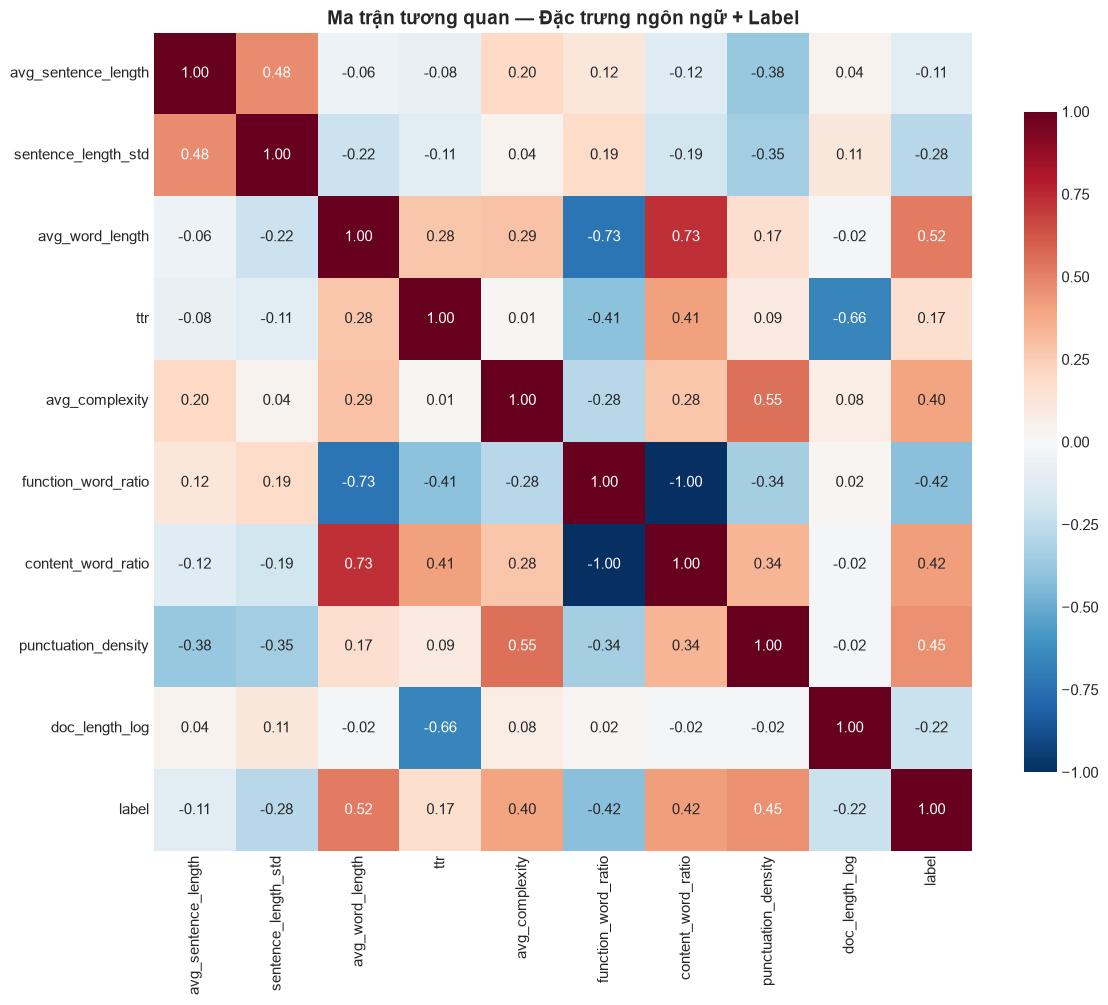

=== Tương quan với label (sắp xếp theo độ mạnh) ===


,correlation_with_label,abs_correlation
avg_word_length,0.5182,0.5182
punctuation_density,0.4549,0.4549
content_word_ratio,0.4184,0.4184
function_word_ratio,-0.4184,0.4184
avg_complexity,0.4037,0.4037
sentence_length_std,-0.2800,0.2800
doc_length_log,-0.2214,0.2214
ttr,0.1710,0.1710
avg_sentence_length,-0.1103,0.1103


In [11]:
# Heatmap tương quan giữa các đặc trưng
corr_matrix = df[feature_names + ['label']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Ma trận tương quan — Đặc trưng ngôn ngữ + Label',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Hiển thị tương quan với label
print("=== Tương quan với label (sắp xếp theo độ mạnh) ===")
label_corr = corr_matrix['label'].drop('label').abs().sort_values(ascending=False)
label_corr_df = pd.DataFrame({
    'correlation_with_label': corr_matrix['label'].drop('label').loc[label_corr.index].round(4),
    'abs_correlation': label_corr.round(4)
})
display(label_corr_df)

## 7. Quan hệ giữa nhãn, chủ đề và nguồn (RQ3)

Phân tích xem các nguồn/thể loại có bị "thuần nhất" về nhãn không — điều này có thể ảnh hưởng đến khả năng tổng quát hóa của mô hình.

=== Phân bố nhãn theo nguồn ===


,Human (0),AI-generated (1),AI_percent
source,,,
NousResearch/Llama-2-7b-chat-hf,0,400,100.0
chat_gpt_moth,0,2421,100.0
cohere-command,0,350,100.0
darragh_claude_v6,0,1000,100.0
darragh_claude_v7,0,1000,100.0
falcon_180b_v1,0,1055,100.0
kingki19_palm,0,1384,100.0
llama2_chat,0,2420,100.0
llama_70b_v1,0,1172,100.0


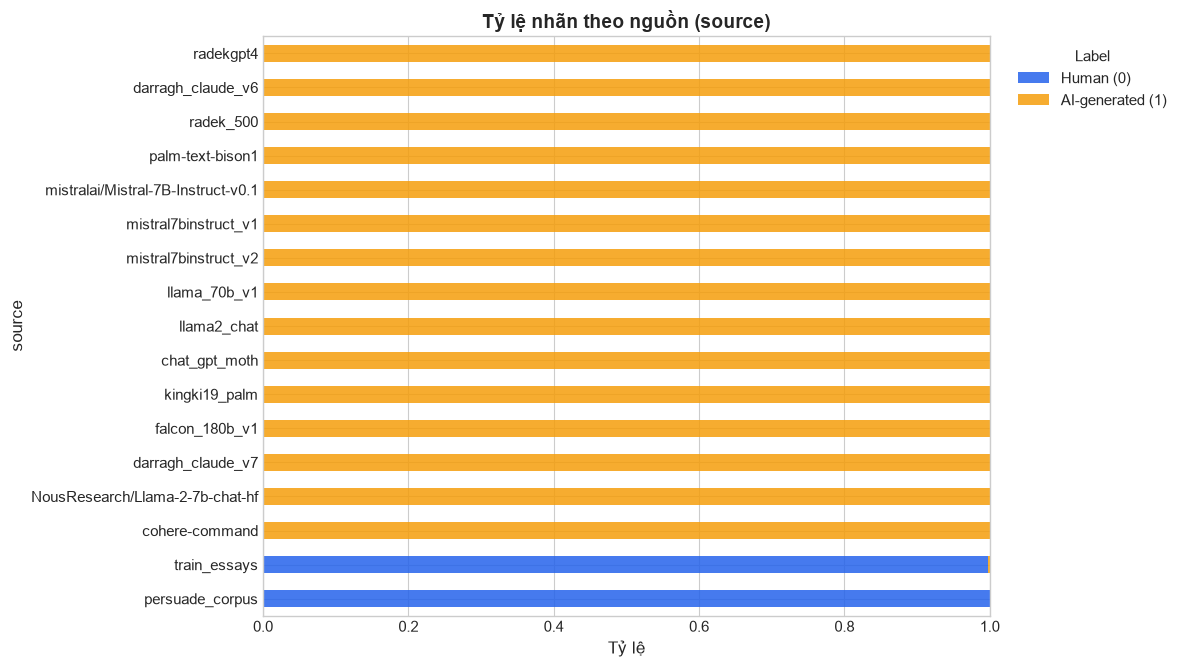


Số nguồn thuần nhất (chỉ có 1 nhãn): 16 / 17


In [12]:
# Phân tích theo nguồn (source)
source_crosstab = pd.crosstab(df['source'], df['label'])
source_crosstab.columns = [LABEL_NAMES[c] for c in source_crosstab.columns]
source_proportion = source_crosstab.div(source_crosstab.sum(axis=1), axis=0)
source_proportion['AI_percent'] = (source_proportion[LABEL_NAMES[LABEL_AI]] * 100).round(1)
source_proportion = source_proportion.sort_values('AI_percent', ascending=True)

print("=== Phân bố nhãn theo nguồn ===")
display(source_crosstab.join(source_proportion[['AI_percent']]))

# Vẽ biểu đồ stacked bar
fig, ax = plt.subplots(figsize=(12, max(6, len(source_proportion) * 0.4)))
source_proportion[[LABEL_NAMES[LABEL_HUMAN], LABEL_NAMES[LABEL_AI]]].plot.barh(
    stacked=True, ax=ax, color=[COLORS[LABEL_HUMAN], COLORS[LABEL_AI]], alpha=0.85
)
ax.set_title('Tỷ lệ nhãn theo nguồn (source)', fontweight='bold', fontsize=14)
ax.set_xlabel('Tỷ lệ')
ax.set_xlim(0, 1)
ax.legend(title='Label', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_label_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

# Đếm số nguồn thuần nhất
pure_sources = (source_crosstab[[LABEL_NAMES[LABEL_HUMAN], LABEL_NAMES[LABEL_AI]]] > 0).sum(axis=1)
pure_count = (pure_sources == 1).sum()
print(f"\nSố nguồn thuần nhất (chỉ có 1 nhãn): {pure_count} / {len(source_crosstab)}")

=== Phân bố nhãn theo chủ đề ===


,Human (0),AI-generated (1),AI_percent
prompt_name,,,
"""A Cowboy Who Rode the Waves""",1372,524,27.6
Car-free cities,2662,2051,43.5
Cell phones at school,1656,463,21.8
Community service,1542,550,26.3
Distance learning,2157,3396,61.2
Does the electoral college work?,2708,1720,38.8
Driverless cars,1886,364,16.2
Exploring Venus,1862,314,14.4
Facial action coding system,2167,917,29.7


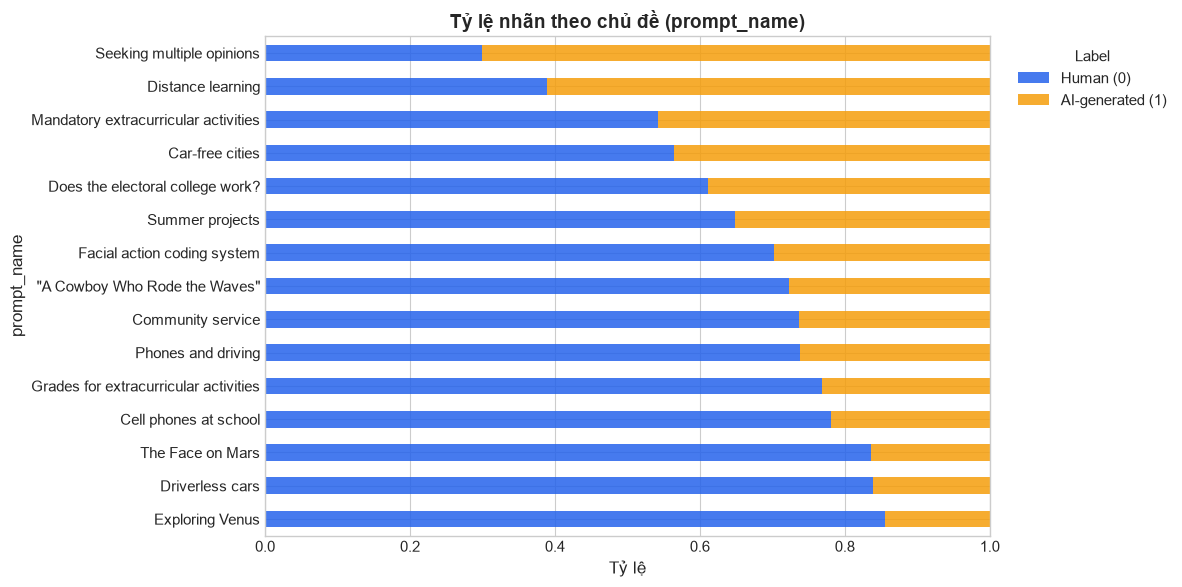

In [13]:
# Phân tích theo chủ đề (prompt_name)
prompt_crosstab = pd.crosstab(df['prompt_name'], df['label'])
prompt_crosstab.columns = [LABEL_NAMES[c] for c in prompt_crosstab.columns]
prompt_proportion = prompt_crosstab.div(prompt_crosstab.sum(axis=1), axis=0)
prompt_proportion['AI_percent'] = (prompt_proportion[LABEL_NAMES[LABEL_AI]] * 100).round(1)
prompt_proportion = prompt_proportion.sort_values('AI_percent', ascending=True)

print("=== Phân bố nhãn theo chủ đề ===")
display(prompt_crosstab.join(prompt_proportion[['AI_percent']]))

fig, ax = plt.subplots(figsize=(12, max(6, len(prompt_proportion) * 0.4)))
prompt_proportion[[LABEL_NAMES[LABEL_HUMAN], LABEL_NAMES[LABEL_AI]]].plot.barh(
    stacked=True, ax=ax, color=[COLORS[LABEL_HUMAN], COLORS[LABEL_AI]], alpha=0.85
)
ax.set_title('Tỷ lệ nhãn theo chủ đề (prompt_name)', fontweight='bold', fontsize=14)
ax.set_xlabel('Tỷ lệ')
ax.set_xlim(0, 1)
ax.legend(title='Label', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '06_label_by_prompt.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Từ và bigram phổ biến theo nhãn


=== TOP 10 UNIGRAM PHỔ BIẾN NHẤT ===

Human (0):


,term,count,per_10000
0,the,542563,474.62
1,to,418353,365.96
2,a,278670,243.77
3,and,276560,241.93
4,of,220833,193.18
5,in,188658,165.03
6,that,186949,163.54
7,is,173222,151.53
8,it,153652,134.41
9,you,142976,125.07



AI-generated (1):


,term,count,per_10000
0,the,220845,382.08
1,and,214229,370.64
2,to,212937,368.40
3,a,146466,253.40
4,of,133674,231.27
5,in,109501,189.45
6,can,81860,141.63
7,that,78836,136.39
8,is,75131,129.98
9,for,69717,120.62


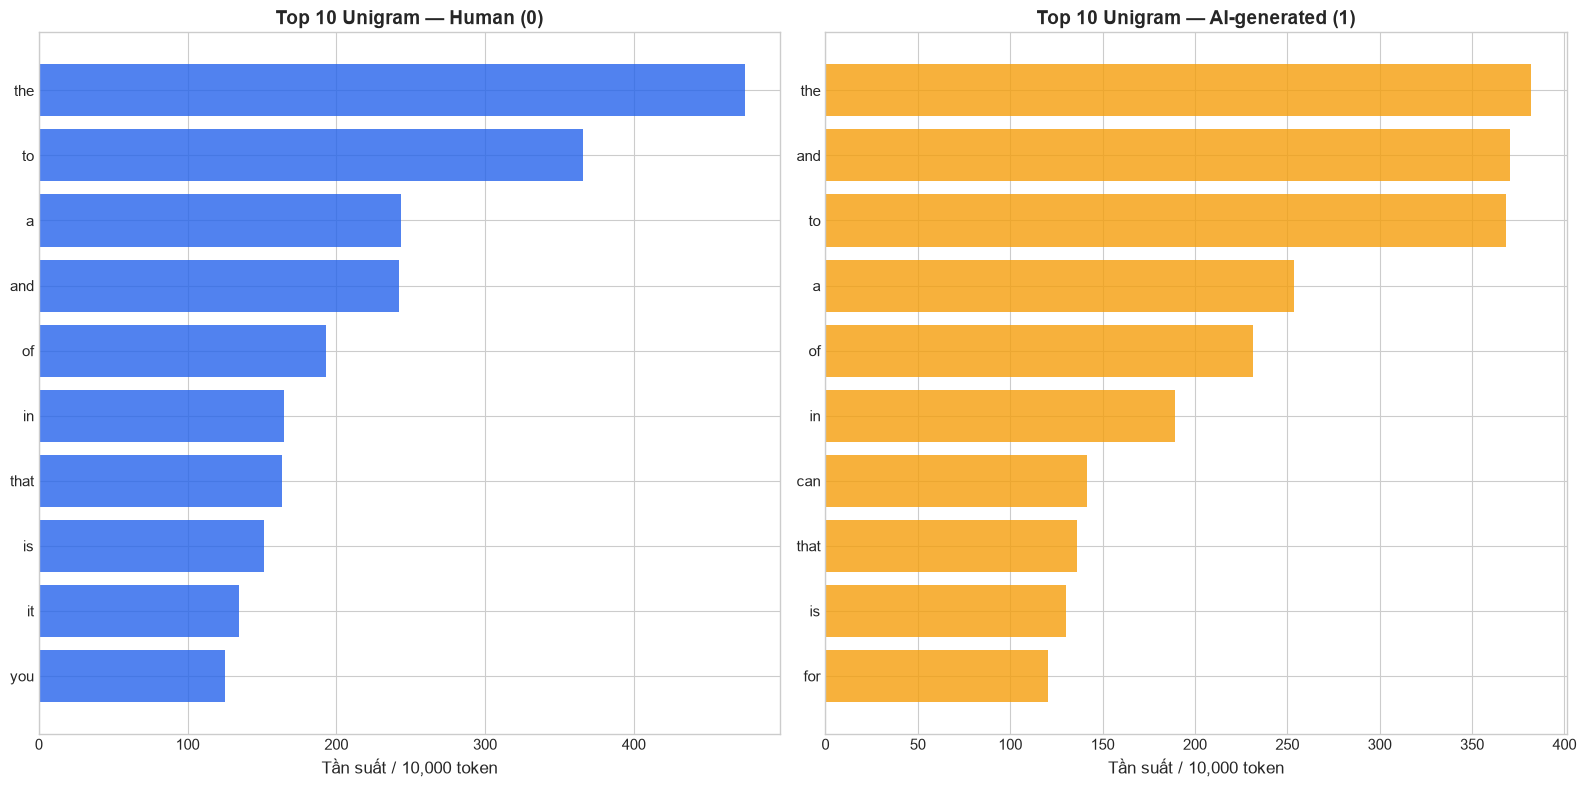


=== TOP 10 BIGRAM PHỔ BIẾN NHẤT ===

Human (0):


,term,count,per_10000
0,of the,44934,39.40
1,in the,43500,38.14
2,to do,24870,21.81
3,to be,24788,21.74
4,it is,22973,20.14
5,would be,22188,19.46
6,to the,21289,18.67
7,on the,20739,18.19
8,is a,20715,18.16
9,for the,19635,17.22



AI-generated (1):


,term,count,per_10000
0,of the,22807,39.58
1,in the,17814,30.91
2,the electoral,15861,27.52
3,electoral college,15487,26.88
4,it is,14687,25.49
5,can be,14606,25.35
6,car usage,14299,24.81
7,can help,11933,20.71
8,on the,11635,20.19
9,limiting car,10049,17.44


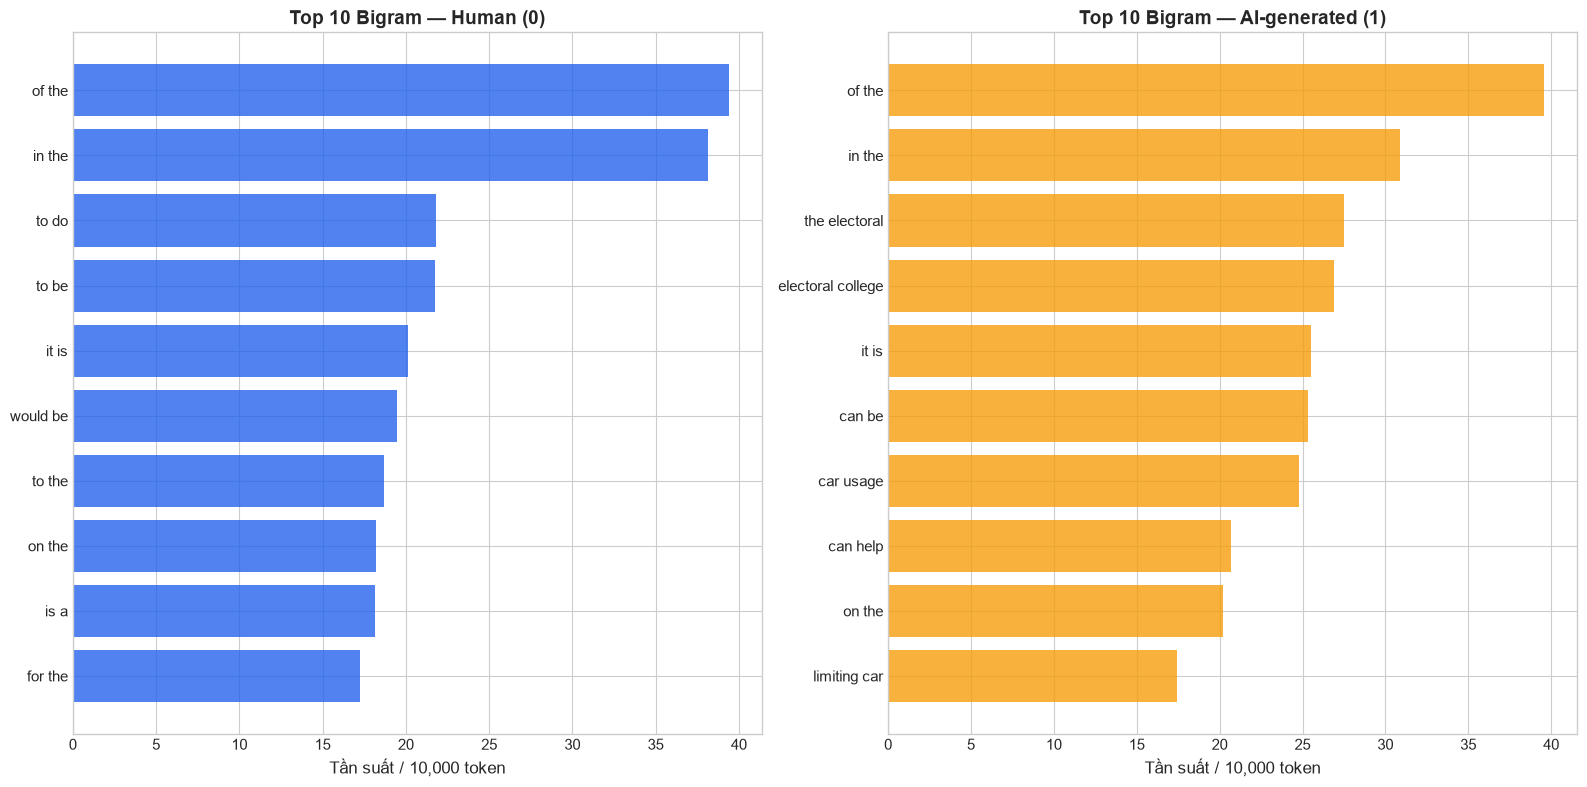

In [14]:
def get_top_terms(texts, n=20, ngram=1):
    """Lấy top n từ/bigram phổ biến nhất."""
    counter = Counter()
    for text in texts:
        tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", str(text).lower())
        if ngram == 1:
            counter.update(tokens)
        else:
            counter.update(' '.join(pair) for pair in zip(tokens, tokens[1:]))
    total = sum(counter.values())
    top = counter.most_common(n)
    return pd.DataFrame(top, columns=['term', 'count']).assign(
        per_10000=lambda x: (x['count'] / max(total, 1) * 10000).round(2)
    )

# Phân tích top từ và bigram
for ngram_name, ngram in [('Unigram', 1), ('Bigram', 2)]:
    print(f"\n{'='*60}")
    print(f"=== TOP 10 {ngram_name.upper()} PHỔ BIẾN NHẤT ===")
    print(f"{'='*60}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    for idx, label in enumerate([LABEL_HUMAN, LABEL_AI]):
        subset = df[df['label'] == label][STANDARD_COLUMNS['text']]
        top_terms = get_top_terms(subset, n=10, ngram=ngram)
        
        print(f"\n{LABEL_NAMES[label]}:")
        display(top_terms)
        
        ax = axes[idx]
        bars = ax.barh(top_terms['term'][::-1], top_terms['per_10000'][::-1],
                       color=COLORS[label], alpha=0.8)
        ax.set_title(f'Top 10 {ngram_name} — {LABEL_NAMES[label]}', fontweight='bold')
        ax.set_xlabel('Tần suất / 10,000 token')
    
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'07_top_{ngram_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Tổng hợp kết quả EDA

In [15]:
# Tổng hợp các kết quả chính
source_table = pd.crosstab(df['source'], df['label'])
pure_sources = int((source_table > 0).sum(axis=1).eq(1).sum())

eda_summary = {
    'total_samples': int(len(df)),
    'label_distribution': {
        LABEL_NAMES[LABEL_HUMAN]: int(label_dist[LABEL_HUMAN]),
        LABEL_NAMES[LABEL_AI]: int(label_dist[LABEL_AI])
    },
    'num_prompts': int(df['prompt_name'].nunique()),
    'num_sources': int(df['source'].nunique()),
    'sources_with_one_label': pure_sources,
    'median_word_count': {
        LABEL_NAMES[LABEL_HUMAN]: float(df[df['label'] == LABEL_HUMAN]['word_count_clean'].median()),
        LABEL_NAMES[LABEL_AI]: float(df[df['label'] == LABEL_AI]['word_count_clean'].median())
    },
    'top_discriminative_features': label_corr_df.head(5).index.tolist(),
    'feature_correlation_with_label': label_corr_df['correlation_with_label'].head(5).to_dict(),
    'figures_saved': [f.name for f in sorted(FIGURES_DIR.glob('*.png'))]
}

print(json.dumps(eda_summary, ensure_ascii=False, indent=2))

# Lưu tổng hợp
summary_path = FIGURES_DIR.parent / 'eda_summary.json'
summary_path.write_text(json.dumps(eda_summary, ensure_ascii=False, indent=2), encoding='utf-8')
print(f"\n✓ Đã lưu tổng hợp EDA tại: {summary_path.resolve()}")
print(f"✓ Đã lưu {len(eda_summary['figures_saved'])} hình ảnh vào: {FIGURES_DIR.resolve()}")

{
  "total_samples": 44854,
  "label_distribution": {
    "Human (0)": 27359,
    "AI-generated (1)": 17495
  },
  "num_prompts": 15,
  "num_sources": 17,
  "sources_with_one_label": 16,
  "median_word_count": {
    "Human (0)": 385.0,
    "AI-generated (1)": 328.0
  },
  "top_discriminative_features": [
    "avg_word_length",
    "punctuation_density",
    "content_word_ratio",
    "function_word_ratio",
    "avg_complexity"
  ],
  "feature_correlation_with_label": {
    "avg_word_length": 0.5182,
    "punctuation_density": 0.4549,
    "content_word_ratio": 0.4184,
    "function_word_ratio": -0.4184,
    "avg_complexity": 0.4037
  },
  "figures_saved": [
    "01_label_prompt_distribution.png",
    "02_text_length_by_label.png",
    "03_linguistic_features_boxplot.png",
    "04_feature_correlation_heatmap.png",
    "05_label_by_source.png",
    "06_label_by_prompt.png",
    "07_top_Bigram.png",
    "07_top_Unigram.png"
  ]
}

✓ Đã lưu tổng hợp EDA tại: H:\FPT\4\DAP\Project-19\AI-Genera

## 10. Kết luận và gợi ý cho bước tiếp theo

### Kết luận EDA:
1. **Dữ liệu không cân bằng**: ~61% Human, ~39% AI-generated
2. **Nhiều nguồn thuần nhất**: Hầu hết các nguồn AI chỉ chứa nhãn 1, nguồn `persuade_corpus` chỉ chứa nhãn 0 → cần cẩn thận khi chia train/test để tránh data leakage và đảm bảo tổng quát hóa
3. **Đặc trưng ngôn ngữ**: Có sự khác biệt rõ rệt giữa Human và AI ở các đặc trưng như... (xem kết quả chi tiết)
4. **Phân bố theo chủ đề**: Tỷ lệ AI/Human khác nhau giữa các chủ đề

### Bước tiếp theo:
- `04_important_feature.ipynb`: Phân tích độ quan trọng của đặc trưng
- `05_LR_RF_LGBM_XGB.ipynb`: Huấn luyện và đánh giá các mô hình máy học truyền thống